In [217]:
import json
import random
import csv
import tensorflow as tf
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import pandas as pd

In [218]:
all_data = json.load(open('./raw_data.json', 'r'))

In [219]:
len(all_data)

820

In [263]:
data = []
check_double = set()
for entry in all_data:
    if entry['task'] == 'classify' and entry['ab'] == 'B':
        unique_key = entry['workerId'] + entry['taskId']
        if unique_key in check_double:
            continue
        check_double.add(unique_key)
        data.extend(dict(item, worker=entry['workerId']) for item in entry['items'])

In [264]:
faces = sorted(set(row['file'] for row in data))

In [265]:
len(data), len(faces)

(8780, 20)

In [266]:
print(f"Resampled {np.mean([row['sample']>1 for row in data])*100:.2f}%")

Resampled 8.13%


In [267]:
def get_vec(state):
    a = state['arousal']/100
    e = (state['expression']/50-1)/2
    a1 = round(min(1, max(0, a - e)), 2)
    a2 = round(min(1, max(0, a + e)), 2)
    return np.array([
        state['valence'] / 100.0,
        a1, a2,
        state['potency'] / 100.0,
        state['contempt'] / 100.0
    ])

def get_data(data, face):
    return [
        {
            "choices": [get_vec(choice) for choice in row['choices']],
            "selected": get_vec(row['choices'][row['selected']]),
        }
        for row in data if row['file'] == face
    ]

In [268]:
def get_mats(DATA):
    numer = np.zeros((5, 1,  len(DATA)))
    denom = np.zeros((5, 15, len(DATA)))
    for j in range(len(DATA)):
        numer[:, 0, j] = DATA[j]['selected']
        for i in range(15):
            denom[:, i, j] = DATA[j]['choices'][i]
    return tf.constant(numer), tf.constant(denom)

def loss(numer, denom, mu, sigma):
    s = tf.exp(sigma)
    #mu = 1/(1+tf.exp(-mu))
    loss1 = tf.math.exp(- tf.reduce_sum((mu - numer)**2 * s, axis= 0))
    loss2 = tf.reduce_sum(
            tf.math.exp(- tf.reduce_sum((mu - denom)**2 * s, axis=0)), axis=0)
    loss = -tf.reduce_sum(tf.math.log(tf.squeeze(loss1)) - tf.math.log(loss2))
    return loss

In [269]:
def fit_model(data):
    RESULT = np.zeros((len(faces), 2, 5))
    for f in range(len(faces)):
        face = faces[f]
        mu = tf.Variable(np.zeros((5,1,1)))
        sigma = tf.Variable(np.zeros((5,1,1)))
        DATA= get_data(data, face)
        opt = tf.keras.optimizers.Adam(learning_rate = 0.01)
        with tf.GradientTape(persistent=True) as tape:
            numer, denom = get_mats(DATA)
            L = lambda: loss(numer, denom, mu, sigma)
        print(f"{face=}: ", end="")
        for epoch in range(20):
            print(f".", end="")
            mu_old = mu.numpy()
            for iter in range(300):
                opt.minimize(L, [mu, sigma], tape=tape)
                mu.assign(tf.math.maximum(mu, 0.0))
                mu.assign(tf.math.minimum(mu, 1.0))
            dist = np.max(np.abs(mu_old - mu.numpy()))
            if dist < 0.0001:
                break
        print()
        RESULT[f,:, :] = [ np.squeeze(mu.numpy()), np.exp(-0.5 * np.squeeze(sigma.numpy())) ]
    return RESULT

In [274]:
def write_result(RESULT, filename):
    RESULT = np.round(RESULT,4)
    with open(f'gen/{filename}', 'w') as out:
        json.dump({
            faces[i] : {
                "x_opt" : RESULT[i][0].tolist(),
                "x_std" : RESULT[i][1].tolist(),
            }
            for i in range(len(faces))
        }, out, indent=2)

In [275]:
RESULT = fit_model(data)
write_result(RESULT, 'resultB.json')

face='img_align_celeba/000838.jpg': ..............
face='img_align_celeba/012499.jpg': ..........
face='img_align_celeba/024857.jpg': .......
face='img_align_celeba/029376.jpg': ...
face='img_align_celeba/036568.jpg': ......
face='img_align_celeba/090689.jpg': ......
face='img_align_celeba/092099.jpg': .........
face='img_align_celeba/093560.jpg': .....
face='img_align_celeba/106786.jpg': ....
face='img_align_celeba/117396.jpg': ..
face='img_align_celeba/128198.jpg': ...
face='img_align_celeba/153630.jpg': ......
face='img_align_celeba/167840.jpg': .....
face='img_align_celeba/168485.jpg': ......
face='img_align_celeba/173110.jpg': ....
face='img_align_celeba/181029.jpg': ..........
face='img_align_celeba/195696.jpg': .......
face='lfw/Joe_Lieberman/Joe_Lieberman_0009.jpg': ......
face='lfw/Ruano_Pascual/Ruano_Pascual_0001.jpg': .....
face='lfw/Saman_Shali/Saman_Shali_0001.jpg': ....


<BarContainer object of 5 artists>

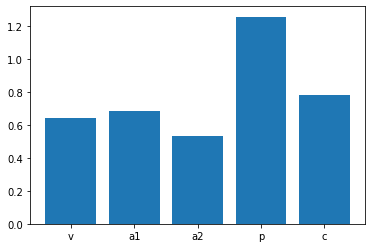

In [276]:
plt.bar(x=['v','a1','a2','p','c'], height=np.mean(RESULT[:,1,:], axis=0))

In [241]:
dims = ['Valence','Arousal in eyes','Arousal in mouth','Potency','Contempt']
print(f"Dimension    & mean $\\mu^*$ & min $\\sigma^*$ & mean $\\sigma^*$ & max $\\sigma^*$ \\\\")
for i in range(5):
    print(f"{dims[i]:20s} & {np.mean(RESULT[:,0,i]):.2f} " +
          f"& {np.min(RESULT[:,1,i]):.2f} " +
          f"& {np.mean(RESULT[:,1,i]):.2f} " 
          f"& {np.max(RESULT[:,1,i]):.2f} \\\\")

Dimension    & mean $\mu^*$ & min $\sigma^*$ & mean $\sigma^*$ & max $\sigma^*$ \\
Valence              & 0.60 & 0.36 & 0.64 & 1.43 \\
Arousal in eyes      & 0.63 & 0.50 & 0.68 & 0.98 \\
Arousal in mouth     & 0.47 & 0.37 & 0.53 & 1.17 \\
Potency              & 0.45 & 0.57 & 1.26 & 6.25 \\
Contempt             & 0.31 & 0.44 & 0.78 & 1.98 \\


In [273]:
a = np.sqrt(5) * np.mean(1/RESULT[:,1,:])
print(f"Sigma corner to corner {a:.2f}")

Sigma corner to corner 3.49


# Bayesian decoding

In [193]:
workers = np.random.permutation(sorted(set(row['worker'] for row in data)))
selected = { workers[i] : i < len(workers)//2 for i in range(len(workers)) } 

In [ ]:
data1 = [row for row in data if selected[row['worker']]]
data2 = [row for row in data if not selected[row['worker']]]
Result1 = fit_model(data1)
Result2 = fit_model(data2)

In [303]:
write_result(Result1, 'resultB1.json')
write_result(Result2, 'resultB2.json')

In [304]:
Z = np.array([
        np.prod([scipy.stats.norm.cdf(1, Result2[i][0][j], Result2[i][1][j])  - 
                 scipy.stats.norm.cdf(0, Result2[i][0][j], Result2[i][1][j]) for j in range(Result1.shape[2])])
        for i in range(Result2.shape[0])
    ])

In [305]:
i= 0
N = 5000
p = np.ones(N)
for j in range(Result1.shape[2]):
    p *= scipy.stats.norm.pdf(np.random.random(N), Result2[i][0][j], Result2[i][1][j])
np.mean(p)/Z[i]

0.9929716544129095

In [306]:
total = 0
successes = 0
y = 5
for i in range(len(faces)):
    mu = Result1[i, 0]
    p0 = np.prod(scipy.stats.norm.pdf(mu, Result2[i, 0], Result2[i, 1])) / Z[i]
    ti = 0
    si = 0
    for j in range(40):
        decoys = np.random.choice(range(len(faces)), y, replace=True)
        ps = [ np.prod(scipy.stats.norm.pdf(mu, Result2[k, 0], Result2[k, 1])) / Z[k] for k in decoys]
        if p0 < np.max(ps):
            success = 0
        else:
            success = 1/(1+np.sum(p0 == ps))
        ti += 1
        si += success
    print(f"{i+1:2d} {faces[i]:41s}: {100 * si/ti:6.2f}")
    total += ti
    successes += si

 1 img_align_celeba/000838.jpg              :  86.25
 2 img_align_celeba/012499.jpg              :  53.75
 3 img_align_celeba/024857.jpg              :  90.00
 4 img_align_celeba/029376.jpg              :  91.25
 5 img_align_celeba/036568.jpg              :  85.42
 6 img_align_celeba/090689.jpg              :  31.25
 7 img_align_celeba/092099.jpg              :  70.42
 8 img_align_celeba/093560.jpg              :  84.58
 9 img_align_celeba/106786.jpg              :  91.25
10 img_align_celeba/117396.jpg              :  95.00
11 img_align_celeba/128198.jpg              :  72.50
12 img_align_celeba/153630.jpg              :  61.25
13 img_align_celeba/167840.jpg              :  84.58
14 img_align_celeba/168485.jpg              :  74.17
15 img_align_celeba/173110.jpg              :  68.33
16 img_align_celeba/181029.jpg              :  36.25
17 img_align_celeba/195696.jpg              :  90.83
18 lfw/Joe_Lieberman/Joe_Lieberman_0009.jpg :  10.00
19 lfw/Ruano_Pascual/Ruano_Pascual_0001.jpg : 

In [307]:
print(f"{successes}/{total} = {100*successes/total:.2f}")
print(f"M={y/(total/successes-1):.2f}")

552.1666666666666/800 = 69.02
M=11.14


# Check faces

[[0.29514472 0.61104803 0.4520554  1.         0.33618263]
 [0.50579863 0.59008601 0.46504443 1.16112733 0.79724552]]


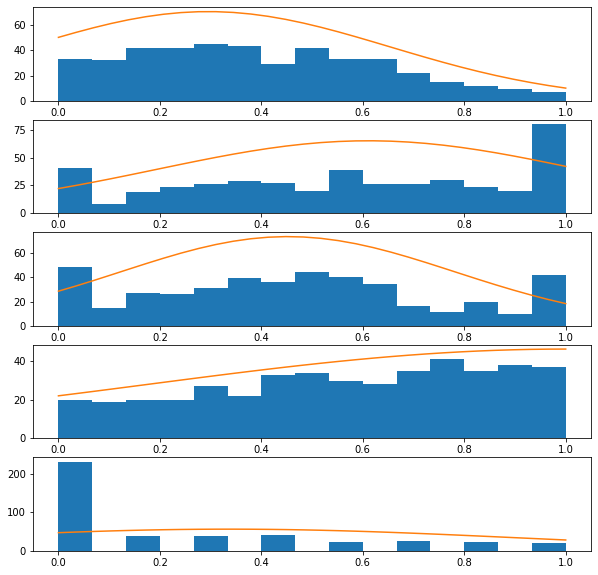

In [197]:
face="img_align_celeba/036568.jpg"
index=faces.index(face)
print(RESULT[index])
DATA= np.array([a['selected'] for a in get_data(data, face)])
fig, ax = plt.subplots(5,1, figsize=(10,10))
x = np.linspace(0,1,30)
for i in range(5):
    ax[i].hist(DATA[:,i],15)
    ax[i].plot(x,50/np.sqrt(RESULT[index,1,i])*np.exp(-(x-RESULT[index,0,i])**2/RESULT[index,1,i]**2))

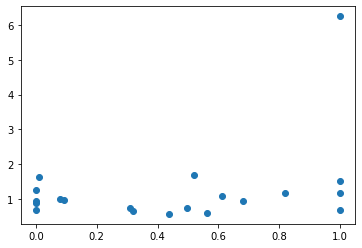

In [293]:
plt.scatter(RESULT[:,0,3], RESULT[:,1,3] )

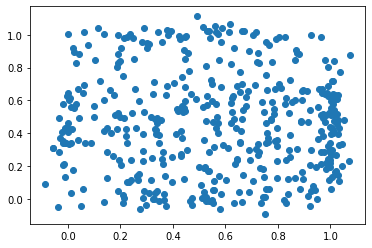

In [277]:
def jitter():
    return 0.03*np.random.normal(0,1,DATA[:,1].shape)
plt.scatter(DATA[:,1]+jitter(), DATA[:,2]+jitter())

In [185]:
np.min(RESULT[:,1,:], axis=0)

array([0.35916381, 0.50463792, 0.36504393, 0.56923342, 0.43937089])

# Trend

In [8]:
trend_data=\
[{'max_n': 20, 'p': 0.5765}, {'max_n': 20, 'p': 0.48316666666666663}, {'max_n': 20, 'p': 0.47508333333333325}, {'max_n': 20, 'p': 0.5505416666666666}, {'max_n': 20, 'p': 0.5752083333333333}, {'max_n': 20, 'p': 0.5875416666666666}, {'max_n': 20, 'p': 0.5607916666666666}, {'max_n': 20, 'p': 0.5262083333333334}, {'max_n': 20, 'p': 0.5444583333333335}, {'max_n': 20, 'p': 0.5770833333333333}, {'max_n': 20, 'p': 0.6419166666666667}, {'max_n': 20, 'p': 0.6131666666666667}, {'max_n': 20, 'p': 0.5494999999999999}, {'max_n': 20, 'p': 0.5618750000000001}, {'max_n': 20, 'p': 0.5688333333333334}, {'max_n': 20, 'p': 0.5690166666666667}, {'max_n': 20, 'p': 0.47566666666666657}, {'max_n': 20, 'p': 0.5478333333333333}, {'max_n': 20, 'p': 0.5235833333333333}, {'max_n': 20, 'p': 0.5389166666666666}, {'max_n': 20, 'p': 0.5829166666666669}, {'max_n': 20, 'p': 0.5954333333333334}, {'max_n': 20, 'p': 0.5671249999999999}, {'max_n': 20, 'p': 0.6117083333333333}, {'max_n': 20, 'p': 0.6818083333333331}, {'max_n': 40, 'p': 0.57825}, {'max_n': 40, 'p': 0.5526249999999999}, {'max_n': 40, 'p': 0.6091666666666666}, {'max_n': 40, 'p': 0.6303333333333334}, {'max_n': 40, 'p': 0.6343749999999999}, {'max_n': 40, 'p': 0.5997083333333334}, {'max_n': 40, 'p': 0.6524166666666666}, {'max_n': 40, 'p': 0.5874166666666666}, {'max_n': 40, 'p': 0.6020416666666667}, {'max_n': 40, 'p': 0.6569583333333335}, {'max_n': 40, 'p': 0.579}, {'max_n': 40, 'p': 0.5961666666666667}, {'max_n': 40, 'p': 0.6409166666666666}, {'max_n': 40, 'p': 0.6519583333333333}, {'max_n': 40, 'p': 0.6544583333333333}, {'max_n': 40, 'p': 0.597125}, {'max_n': 40, 'p': 0.6245}, {'max_n': 40, 'p': 0.6450833333333333}, {'max_n': 40, 'p': 0.5679583333333333}, {'max_n': 40, 'p': 0.5418749999999999}, {'max_n': 40, 'p': 0.5831666666666666}, {'max_n': 40, 'p': 0.6612916666666667}, {'max_n': 40, 'p': 0.6793333333333333}, {'max_n': 40, 'p': 0.706875}, {'max_n': 40, 'p': 0.5914166666666667}, {'max_n': 60, 'p': 0.6997083333333332}, {'max_n': 60, 'p': 0.6942500000000001}, {'max_n': 60, 'p': 0.604}, {'max_n': 60, 'p': 0.572875}, {'max_n': 60, 'p': 0.6112083333333332}, {'max_n': 60, 'p': 0.6355583333333332}, {'max_n': 60, 'p': 0.6254749999999999}, {'max_n': 60, 'p': 0.6288750000000001}, {'max_n': 60, 'p': 0.7057083333333332}, {'max_n': 60, 'p': 0.6711250000000001}, {'max_n': 60, 'p': 0.6275416666666667}, {'max_n': 60, 'p': 0.617625}, {'max_n': 60, 'p': 0.6464583333333332}, {'max_n': 60, 'p': 0.6651666666666668}, {'max_n': 60, 'p': 0.6586250000000001}, {'max_n': 60, 'p': 0.6522500000000001}, {'max_n': 60, 'p': 0.6844166666666666}, {'max_n': 60, 'p': 0.6668333333333333}, {'max_n': 60, 'p': 0.6271}, {'max_n': 60, 'p': 0.6944999999999997}, {'max_n': 60, 'p': 0.6872249999999999}, {'max_n': 60, 'p': 0.6562500000000001}, {'max_n': 60, 'p': 0.6200416666666666}, {'max_n': 60, 'p': 0.6785833333333333}, {'max_n': 60, 'p': 0.5831249999999999}, {'max_n': 80, 'p': 0.6724166666666667}, {'max_n': 80, 'p': 0.6819583333333332}, {'max_n': 80, 'p': 0.6437916666666667}, {'max_n': 80, 'p': 0.6945}, {'max_n': 80, 'p': 0.7057500000000001}, {'max_n': 80, 'p': 0.6959999999999998}, {'max_n': 80, 'p': 0.6317083333333333}, {'max_n': 80, 'p': 0.6264999999999998}, {'max_n': 80, 'p': 0.6507083333333333}, {'max_n': 80, 'p': 0.6475416666666667}, {'max_n': 80, 'p': 0.5995833333333332}, {'max_n': 80, 'p': 0.6657499999999998}, {'max_n': 80, 'p': 0.6446666666666666}, {'max_n': 80, 'p': 0.6404999999999998}, {'max_n': 80, 'p': 0.6596666666666666}, {'max_n': 80, 'p': 0.6764583333333334}, {'max_n': 80, 'p': 0.6864166666666668}, {'max_n': 80, 'p': 0.6522666666666666}, {'max_n': 80, 'p': 0.7105416666666666}, {'max_n': 80, 'p': 0.7630833333333332}, {'max_n': 80, 'p': 0.6420833333333333}, {'max_n': 80, 'p': 0.7005}, {'max_n': 80, 'p': 0.6654583333333333}, {'max_n': 80, 'p': 0.6847083333333334}, {'max_n': 80, 'p': 0.6615833333333334},
{'max_n': 120, 'p': 0.6641249999999999}, {'max_n': 120, 'p': 0.6940833333333334}, {'max_n': 120, 'p': 0.6822916666666665}, {'max_n': 120, 'p': 0.6707499999999998}, {'max_n': 120, 'p': 0.6519166666666667}, {'max_n': 120, 'p': 0.6139166666666668}, {'max_n': 120, 'p': 0.6394999999999998}, {'max_n': 120, 'p': 0.7060416666666667}, {'max_n': 120, 'p': 0.7098333333333333}, {'max_n': 120, 'p': 0.7062083333333332}, {'max_n': 120, 'p': 0.6312916666666666}, {'max_n': 120, 'p': 0.6913333333333334}, {'max_n': 120, 'p': 0.6979999999999997}, {'max_n': 120, 'p': 0.6603750000000002}, {'max_n': 120, 'p': 0.6989583333333333}, {'max_n': 120, 'p': 0.6984583333333333}, {'max_n': 120, 'p': 0.6960416666666668}, {'max_n': 120, 'p': 0.7101249999999999}, {'max_n': 120, 'p': 0.6675416666666665}, {'max_n': 120, 'p': 0.6757916666666668}, {'max_n': 120, 'p': 0.7280416666666665}, {'max_n': 120, 'p': 0.7254166666666667}, {'max_n': 120, 'p': 0.65125}, {'max_n': 120, 'p': 0.69725}, {'max_n': 120, 'p': 0.7194583333333334}, {'max_n': 140, 'p': 0.6538333333333333}, {'max_n': 140, 'p': 0.6609583333333331}, {'max_n': 140, 'p': 0.7097499999999999}, {'max_n': 140, 'p': 0.6695416666666666}, {'max_n': 140, 'p': 0.6847499999999999}, {'max_n': 140, 'p': 0.6462916666666667}, {'max_n': 140, 'p': 0.6586666666666666}, {'max_n': 140, 'p': 0.6948333333333333}, {'max_n': 140, 'p': 0.7539583333333333}, {'max_n': 140, 'p': 0.7034583333333333}, {'max_n': 140, 'p': 0.7132916666666665}, {'max_n': 140, 'p': 0.7148333333333332}, {'max_n': 140, 'p': 0.6574166666666666}, {'max_n': 140, 'p': 0.6553749999999999}, {'max_n': 140, 'p': 0.6815416666666667}, {'max_n': 140, 'p': 0.7085833333333332}, {'max_n': 140, 'p': 0.6742500000000001}, {'max_n': 140, 'p': 0.70775}, {'max_n': 140, 'p': 0.6892083333333334}, {'max_n': 140, 'p': 0.7207500000000001}, {'max_n': 140, 'p': 0.6591}, {'max_n': 140, 'p': 0.7564166666666666}, {'max_n': 140, 'p': 0.73735}, {'max_n': 140, 'p': 0.6848916666666667}, {'max_n': 140, 'p': 0.7542499999999999}, {'max_n': 160, 'p': 0.7039166666666666}, {'max_n': 160, 'p': 0.7152083333333332}, {'max_n': 160, 'p': 0.7069166666666665}, {'max_n': 160, 'p': 0.7008083333333331}, {'max_n': 160, 'p': 0.6633333333333333}, {'max_n': 160, 'p': 0.703125}, {'max_n': 160, 'p': 0.6557499999999998}, {'max_n': 160, 'p': 0.6753333333333333}, {'max_n': 160, 'p': 0.6874583333333333}, {'max_n': 160, 'p': 0.6852083333333332}, {'max_n': 160, 'p': 0.7397916666666667}, {'max_n': 160, 'p': 0.7262083333333332}, {'max_n': 160, 'p': 0.6867499999999999}, {'max_n': 160, 'p': 0.6882083333333335}, {'max_n': 160, 'p': 0.6415833333333333}, {'max_n': 160, 'p': 0.7497916666666665}, {'max_n': 160, 'p': 0.6682916666666666}, {'max_n': 160, 'p': 0.6708333333333335}, {'max_n': 160, 'p': 0.7575}, {'max_n': 160, 'p': 0.7462916666666668}, {'max_n': 160, 'p': 0.720625}, {'max_n': 160, 'p': 0.6571249999999998}, {'max_n': 160, 'p': 0.6689166666666667}, {'max_n': 160, 'p': 0.6970416666666668}, {'max_n': 160, 'p': 0.6865416666666667}, {'max_n': 180, 'p': 0.7122916666666667}, {'max_n': 180, 'p': 0.727875}, {'max_n': 180, 'p': 0.7820833333333334}, {'max_n': 180, 'p': 0.7082083333333333}, {'max_n': 180, 'p': 0.6974166666666668}, {'max_n': 180, 'p': 0.7048333333333333}, {'max_n': 180, 'p': 0.7329333333333334}, {'max_n': 180, 'p': 0.6270416666666665}, {'max_n': 180, 'p': 0.6938749999999999}, {'max_n': 180, 'p': 0.7208749999999999}, {'max_n': 180, 'p': 0.6459166666666666}, {'max_n': 180, 'p': 0.7025416666666666}, {'max_n': 180, 'p': 0.6607083333333333}, {'max_n': 180, 'p': 0.6952083333333335}, {'max_n': 180, 'p': 0.6639583333333333}, {'max_n': 180, 'p': 0.6993333333333334}, {'max_n': 180, 'p': 0.6864583333333332}, {'max_n': 180, 'p': 0.6799583333333332}, {'max_n': 180, 'p': 0.698}, {'max_n': 180, 'p': 0.6945416666666666}, {'max_n': 180, 'p': 0.6822666666666667}, {'max_n': 180, 'p': 0.6635416666666666}, {'max_n': 180, 'p': 0.7067500000000001}, {'max_n': 180, 'p': 0.7283749999999999}, {'max_n': 180, 'p': 0.6779749999999999}]
trend_data_2=\
[{'max_n': 20, 'p': 0.6665416666666665}, {'max_n': 20, 'p': 0.49191666666666667}, {'max_n': 20, 'p': 0.5630416666666667}, {'max_n': 20, 'p': 0.5133333333333333}, {'max_n': 20, 'p': 0.5726666666666667}, {'max_n': 20, 'p': 0.5870583333333332}, {'max_n': 20, 'p': 0.5746666666666667}, {'max_n': 20, 'p': 0.5427916666666668}, {'max_n': 20, 'p': 0.5777916666666666}, {'max_n': 20, 'p': 0.5772083333333333}, {'max_n': 20, 'p': 0.5812499999999999}, {'max_n': 20, 'p': 0.5346666666666666}, {'max_n': 20, 'p': 0.5812916666666665}, {'max_n': 20, 'p': 0.5915833333333333}, {'max_n': 20, 'p': 0.579}, {'max_n': 20, 'p': 0.6369583333333332}, {'max_n': 20, 'p': 0.49291666666666667}, {'max_n': 20, 'p': 0.5634166666666667}, {'max_n': 20, 'p': 0.5679166666666666}, {'max_n': 20, 'p': 0.6231250000000002}, {'max_n': 20, 'p': 0.5547916666666668}, {'max_n': 20, 'p': 0.7225416666666666}, {'max_n': 20, 'p': 0.5748333333333334}, {'max_n': 20, 'p': 0.5317916666666667}, {'max_n': 20, 'p': 0.5270416666666666}, {'max_n': 40, 'p': 0.6404166666666666}, {'max_n': 40, 'p': 0.6514999999999999}, {'max_n': 40, 'p': 0.57375}, {'max_n': 40, 'p': 0.6257499999999999}, {'max_n': 40, 'p': 0.6539999999999999}, {'max_n': 40, 'p': 0.6026249999999999}, {'max_n': 40, 'p': 0.6862499999999999}, {'max_n': 40, 'p': 0.6351249999999999}, {'max_n': 40, 'p': 0.7182083333333332}, {'max_n': 40, 'p': 0.6245000000000002}, {'max_n': 40, 'p': 0.6340000000000001}, {'max_n': 40, 'p': 0.6029166666666667}, {'max_n': 40, 'p': 0.605}, {'max_n': 40, 'p': 0.5779999999999998}, {'max_n': 40, 'p': 0.6335833333333334}, {'max_n': 40, 'p': 0.6613333333333334}, {'max_n': 40, 'p': 0.625375}, {'max_n': 40, 'p': 0.6622916666666667}, {'max_n': 40, 'p': 0.6442500000000001}, {'max_n': 40, 'p': 0.5911249999999999}, {'max_n': 40, 'p': 0.5930416666666666}, {'max_n': 40, 'p': 0.6327083333333331}, {'max_n': 40, 'p': 0.6248749999999998}, {'max_n': 40, 'p': 0.6234583333333332}, {'max_n': 40, 'p': 0.5730833333333333}, {'max_n': 60, 'p': 0.633875}, {'max_n': 60, 'p': 0.68435}, {'max_n': 60, 'p': 0.6936166666666665}, {'max_n': 60, 'p': 0.6558333333333333}, {'max_n': 60, 'p': 0.6563333333333332}, {'max_n': 60, 'p': 0.6954166666666669}, {'max_n': 60, 'p': 0.6637083333333331}, {'max_n': 60, 'p': 0.6598749999999999}, {'max_n': 60, 'p': 0.6982916666666666}, {'max_n': 60, 'p': 0.6860416666666668}, {'max_n': 60, 'p': 0.6322916666666667}, {'max_n': 60, 'p': 0.6684999999999999}, {'max_n': 60, 'p': 0.7354999999999999}, {'max_n': 60, 'p': 0.6875000000000001}, {'max_n': 60, 'p': 0.6132083333333332}, {'max_n': 60, 'p': 0.6404166666666666}, {'max_n': 60, 'p': 0.6258333333333332}, {'max_n': 60, 'p': 0.6794583333333332}, {'max_n': 60, 'p': 0.6554166666666666}, {'max_n': 60, 'p': 0.68375}, {'max_n': 60, 'p': 0.7005416666666666}, {'max_n': 60, 'p': 0.6194999999999999}, {'max_n': 60, 'p': 0.6523333333333333}, {'max_n': 60, 'p': 0.7130416666666668}, {'max_n': 60, 'p': 0.63375}, {'max_n': 80, 'p': 0.7208333333333332}, {'max_n': 80, 'p': 0.6614166666666668}, {'max_n': 80, 'p': 0.6714166666666667}, {'max_n': 80, 'p': 0.6229583333333333}, {'max_n': 80, 'p': 0.6597916666666668}, {'max_n': 80, 'p': 0.6593916666666666}, {'max_n': 80, 'p': 0.6547083333333332}, {'max_n': 80, 'p': 0.7406666666666666}, {'max_n': 80, 'p': 0.6719166666666667}, {'max_n': 80, 'p': 0.6954166666666665}, {'max_n': 80, 'p': 0.6425416666666667}, {'max_n': 80, 'p': 0.6924166666666666}, {'max_n': 80, 'p': 0.7045833333333333}, {'max_n': 80, 'p': 0.70025}, {'max_n': 80, 'p': 0.6370416666666666}, {'max_n': 80, 'p': 0.6289583333333333}, {'max_n': 80, 'p': 0.6630416666666665}, {'max_n': 80, 'p': 0.7124583333333335}, {'max_n': 80, 'p': 0.6214583333333332}, {'max_n': 80, 'p': 0.6364166666666666}, {'max_n': 80, 'p': 0.6985833333333333}, {'max_n': 80, 'p': 0.6426666666666666}, {'max_n': 80, 'p': 0.6328333333333334}, {'max_n': 80, 'p': 0.6654583333333333}, {'max_n': 80, 'p': 0.6667083333333333}, {'max_n': 100, 'p': 0.72025}, {'max_n': 100, 'p': 0.66825}, {'max_n': 100, 'p': 0.6677916666666668}, {'max_n': 100, 'p': 0.6941666666666666}, {'max_n': 100, 'p': 0.6851249999999999}, {'max_n': 100, 'p': 0.6561666666666668}, {'max_n': 100, 'p': 0.7398916666666666}, {'max_n': 100, 'p': 0.6534166666666666}, {'max_n': 100, 'p': 0.7064166666666666}, {'max_n': 100, 'p': 0.6725416666666666}, {'max_n': 100, 'p': 0.6413333333333331}, {'max_n': 100, 'p': 0.6938749999999998}, {'max_n': 100, 'p': 0.65525}, {'max_n': 100, 'p': 0.7619583333333334}, {'max_n': 100, 'p': 0.6892916666666666}, {'max_n': 100, 'p': 0.64175}, {'max_n': 100, 'p': 0.6710833333333335}, {'max_n': 100, 'p': 0.6879999999999998}, {'max_n': 100, 'p': 0.6420833333333332}, {'max_n': 100, 'p': 0.6661666666666666}, {'max_n': 100, 'p': 0.658625}, {'max_n': 100, 'p': 0.6535416666666666}, {'max_n': 100, 'p': 0.7006416666666666}, {'max_n': 100, 'p': 0.6494166666666668}, {'max_n': 100, 'p': 0.6826250000000003}, {'max_n': 120, 'p': 0.642875}, {'max_n': 120, 'p': 0.7055833333333335}, {'max_n': 120, 'p': 0.6832500000000001}, {'max_n': 120, 'p': 0.7336666666666666}, {'max_n': 120, 'p': 0.7013333333333331}, {'max_n': 120, 'p': 0.7085}, {'max_n': 120, 'p': 0.665125}, {'max_n': 120, 'p': 0.6901666666666666}, {'max_n': 120, 'p': 0.6989166666666666}, {'max_n': 120, 'p': 0.7165000000000001}, {'max_n': 120, 'p': 0.6962083333333333}, {'max_n': 120, 'p': 0.6734999999999999}, {'max_n': 120, 'p': 0.7015833333333332}, {'max_n': 120, 'p': 0.6450833333333333}, {'max_n': 120, 'p': 0.7049583333333334}, {'max_n': 120, 'p': 0.6717083333333334}, {'max_n': 120, 'p': 0.7035833333333333}, {'max_n': 120, 'p': 0.7205416666666665}, {'max_n': 120, 'p': 0.6842500000000001}, {'max_n': 120, 'p': 0.6585833333333333}, {'max_n': 120, 'p': 0.6856666666666666}, {'max_n': 120, 'p': 0.6416249999999999}, {'max_n': 120, 'p': 0.6559583333333333}, {'max_n': 120, 'p': 0.6862916666666666}, {'max_n': 120, 'p': 0.7003749999999999}, {'max_n': 140, 'p': 0.6798333333333333}, {'max_n': 140, 'p': 0.6837916666666669}, {'max_n': 140, 'p': 0.6949166666666666}, {'max_n': 140, 'p': 0.6460833333333333}, {'max_n': 140, 'p': 0.690375}, {'max_n': 140, 'p': 0.6472083333333333}, {'max_n': 140, 'p': 0.6722916666666667}, {'max_n': 140, 'p': 0.660875}, {'max_n': 140, 'p': 0.6695}, {'max_n': 140, 'p': 0.6319999999999999}, {'max_n': 140, 'p': 0.6762499999999999}, {'max_n': 140, 'p': 0.6985833333333332}, {'max_n': 140, 'p': 0.7064166666666666}, {'max_n': 140, 'p': 0.7070416666666666}, {'max_n': 140, 'p': 0.6852083333333332}, {'max_n': 140, 'p': 0.7042916666666668}, {'max_n': 140, 'p': 0.6679583333333332}, {'max_n': 140, 'p': 0.67175}, {'max_n': 140, 'p': 0.6579166666666667}, {'max_n': 140, 'p': 0.6875416666666666}, {'max_n': 140, 'p': 0.6468333333333333}, {'max_n': 140, 'p': 0.6884583333333333}, {'max_n': 140, 'p': 0.6873333333333334}, {'max_n': 140, 'p': 0.6983333333333333}, {'max_n': 140, 'p': 0.7232916666666668}, {'max_n': 160, 'p': 0.6960833333333334}, {'max_n': 160, 'p': 0.675875}, {'max_n': 160, 'p': 0.6766666666666667}, {'max_n': 160, 'p': 0.6775}, {'max_n': 160, 'p': 0.6730416666666665}, {'max_n': 160, 'p': 0.7040416666666666}, {'max_n': 160, 'p': 0.64775}, {'max_n': 160, 'p': 0.6779999999999998}, {'max_n': 160, 'p': 0.6765416666666667}, {'max_n': 160, 'p': 0.6782083333333332}, {'max_n': 160, 'p': 0.7437916666666666}, {'max_n': 160, 'p': 0.6779583333333333}, {'max_n': 160, 'p': 0.6243333333333334}, {'max_n': 160, 'p': 0.6722499999999999}, {'max_n': 160, 'p': 0.7377083333333334}, {'max_n': 160, 'p': 0.7070416666666668}, {'max_n': 160, 'p': 0.6725416666666667}, {'max_n': 160, 'p': 0.6945}, {'max_n': 160, 'p': 0.6312916666666666}, {'max_n': 160, 'p': 0.6647083333333333}, {'max_n': 160, 'p': 0.6924166666666666}, {'max_n': 160, 'p': 0.7004583333333333}, {'max_n': 160, 'p': 0.6424583333333331}, {'max_n': 160, 'p': 0.7143749999999999}, {'max_n': 160, 'p': 0.6510000000000001}, {'max_n': 180, 'p': 0.689291666666667}, {'max_n': 180, 'p': 0.6827916666666665}, {'max_n': 180, 'p': 0.6999999999999997}, {'max_n': 180, 'p': 0.6972083333333333}, {'max_n': 180, 'p': 0.7005833333333333}, {'max_n': 180, 'p': 0.6879166666666666}, {'max_n': 180, 'p': 0.6880833333333334}, {'max_n': 180, 'p': 0.7234999999999999}, {'max_n': 180, 'p': 0.7385833333333334}, {'max_n': 180, 'p': 0.6846666666666665}, {'max_n': 180, 'p': 0.6986249999999999}, {'max_n': 180, 'p': 0.6582916666666668}, {'max_n': 180, 'p': 0.6941833333333333}, {'max_n': 180, 'p': 0.6619166666666665}, {'max_n': 180, 'p': 0.6716249999999999}, {'max_n': 180, 'p': 0.717875}, {'max_n': 180, 'p': 0.6642499999999999}, {'max_n': 180, 'p': 0.7136}, {'max_n': 180, 'p': 0.6750416666666668}, {'max_n': 180, 'p': 0.7052916666666668}, {'max_n': 180, 'p': 0.6907833333333334}, {'max_n': 180, 'p': 0.7022916666666666}, {'max_n': 180, 'p': 0.668625}, {'max_n': 180, 'p': 0.7161666666666667}, {'max_n': 180, 'p': 0.708125}, {'max_n': 200, 'p': 0.7207500000000001}, {'max_n': 200, 'p': 0.6944166666666665}, {'max_n': 200, 'p': 0.70825}, {'max_n': 200, 'p': 0.6867083333333335}, {'max_n': 200, 'p': 0.7046666666666667}, {'max_n': 200, 'p': 0.7082916666666665}, {'max_n': 200, 'p': 0.7185833333333334}, {'max_n': 200, 'p': 0.6978333333333334}, {'max_n': 200, 'p': 0.6858333333333333}, {'max_n': 200, 'p': 0.6917083333333331}, {'max_n': 200, 'p': 0.7292916666666669}, {'max_n': 200, 'p': 0.7231249999999999}, {'max_n': 200, 'p': 0.6956249999999999}, {'max_n': 200, 'p': 0.7025000000000001}, {'max_n': 200, 'p': 0.726625}, {'max_n': 200, 'p': 0.7022499999999999}, {'max_n': 200, 'p': 0.6885833333333332}, {'max_n': 200, 'p': 0.7318333333333332}, {'max_n': 200, 'p': 0.7026666666666666}, {'max_n': 200, 'p': 0.7024583333333334}, {'max_n': 200, 'p': 0.6937083333333333}, {'max_n': 200, 'p': 0.752375}, {'max_n': 200, 'p': 0.73275}, {'max_n': 200, 'p': 0.7073333333333335}, {'max_n': 200, 'p': 0.7069166666666666}]



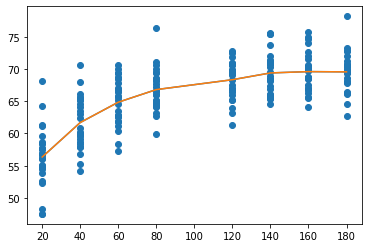

In [11]:
trend = pd.DataFrame(trend_data)
agg = trend.groupby('max_n').mean().reset_index()
plt.plot(agg['max_n'], 100*agg['p'])
plt.scatter(trend['max_n'], 100*trend['p'])

trend2 = pd.DataFrame(trend_data_2)
agg2 = trend.groupby('max_n').mean().reset_index()
plt.plot(agg2['max_n'], 100*agg2['p'])

In [345]:
agg

,max_n,p
0,20,0.563435
1,40,0.616977
2,60,0.648581
3,80,0.668166
4,120,0.683520
5,140,0.694042
6,160,0.696102
7,180,0.695719
